In [1]:
import numpy as np
import matplotlib.pyplot as plt

Using relationship in Atlas et al. (1973), 
$$v_t(D)=9.65-10.3\exp(-0.6D)$$
where $v_t$ is terminal velocity in [m/s] and $D$ is rain droplet diameter in [mm].
we can derive the expected error as a function of terminal velocity error using $\delta D=\delta v_t\left|\frac{dD}{dv_t}\right|$:
$$\delta D=0.1618\exp(0.6D)\delta v_t$$

Note: We know our uncertainties come from the relationship between terminal velocity and relative droplet velocity $v_t=v_d-v_w$, where $v_d$ is droplet velocity and $v_w$ is vertical wind:
$$\delta v_t=\sqrt{\delta v_d^2+\delta v_w^2}$$

With velocimetry, we get $\delta v_d\ll\delta v_w$ because of our ultra-high-resolution sampling, so $\delta v_t=\delta v_w$.

In [2]:
dv_t = np.logspace(-2, 0, 5)  # [m/s]
D = np.linspace(0.1, 5, 100)

dD = 0.1618 * np.exp(0.6 * D) * dv_t[:, None]  # [mm]

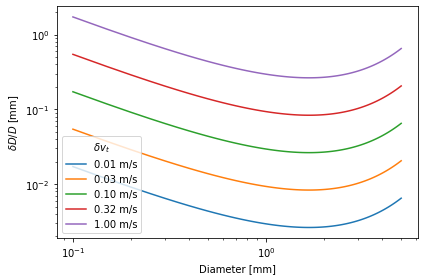

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111)
for i in range(np.shape(dD)[0]):
    ax.plot(D, dD[i, :]/D, label='{:.2f} m/s'.format(dv_t[i]))
ax.set_xlabel('Diameter [mm]')
ax.set_ylabel('$\delta D/D$ [mm]')
ax.set_yscale('log')
ax.set_xscale('log')
plt.legend(title='$\delta v_t$')
plt.tight_layout()
plt.show()

Now, we want to understand how laser pulse and integration time interacts with velocity precision. Using the Doppler relationship:
$$\sigma_f=\frac{2\sigma_v}{\lambda}$$
where $\sigma_f$ is Doppler frequency precision, $\sigma_v$ is Doppler velocity precision, and $\lambda$ is wavelength. We also know that Doppler frequency precision is related to bandwidth via
$$\sigma_f\sim\frac{1}{\tau}$$
where $\tau$ is pulse width. Assuming stationarity over integration, then we can increase precision by
$$\sigma_{f,N}\sim\frac{1}{\tau\sqrt{N}}$$
where $N$ is the number of INDEPENDENT integrated profiles. 

### Requirement: $N$ needs to be independent samples. So noncorrelated profiles. ###

In [10]:
PRF = 20e3  # [Hz]
lamb = 1064e-9  # [m]
tau = 50e-9  # [s]
sigma_v = 0.1  # [m/s]

T_int = lamb**2 / PRF / 4 / sigma_v**2 / tau**2  # [s] 

print('Example integrated time: {:.2f} s'.format(T_int)) 

Example integrated time: 0.57 s
